# 第三周作业 数据可视化
任务背景：将继续沿用上一次作业的studentInfo.csv（学生基本信息）、studentAssessment.csv（学生评分记录）和assessment.csv（评分标准）三张数据表。

任务描述：
1. 绘制一个折线图，展示学生通过率随imd_band（贫困指数）变化情况。
2. 绘制一个箱线图，横轴为gender，纵轴为上次任务的平均成绩mean_score，直观对比男女生的成绩分布中位数和异常值。
3. 绘制一个堆叠柱状图，展示各课程的最终结果百分比分布图，柱子内部按final_result进行堆叠。

最终提交：
- 数据处理程序代码（本文件）
- 绘制的三张图表

本任务允许且鼓励你使用AI工具辅助完成，如果使用，在下方AI对话记录板块粘贴对话链接。

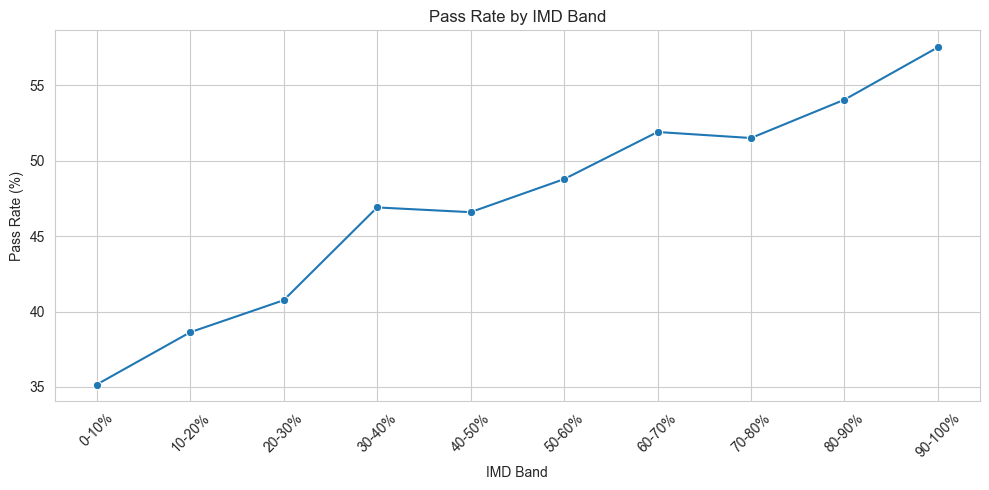

,imd_band,pass_rate
0,0-10%,35.155542
1,10-20%,38.623436
2,20-30%,40.749863
3,30-40%,46.905906
4,40-50%,46.590909
5,50-60%,48.783611
6,60-70%,51.910499
7,70-80%,51.510941
8,80-90%,54.055033
9,90-100%,57.531546


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 第一题：绘制 imd_band 与学生通过率的折线图
student_info = pd.read_csv("studentInfo.csv", encoding="gb18030")

# 修正 imd_band 中被错误识别成日期的类别，并保留有序分类顺序
student_info["imd_band"] = student_info["imd_band"].replace("10月20日", "10-20%")
imd_order = [
    "0-10%", "10-20%", "20-30%", "30-40%", "40-50%",
    "50-60%", "60-70%", "70-80%", "80-90%", "90-100%"
]

# Pass 和 Distinction 视为通过
student_info["is_pass"] = student_info["final_result"].isin(["Pass", "Distinction"])

pass_rate_by_imd = (
    student_info.dropna(subset=["imd_band"])
    .groupby("imd_band", as_index=False)["is_pass"]
    .mean()
)
pass_rate_by_imd["pass_rate"] = pass_rate_by_imd["is_pass"] * 100
pass_rate_by_imd["imd_band"] = pd.Categorical(
    pass_rate_by_imd["imd_band"],
    categories=imd_order,
    ordered=True
)
pass_rate_by_imd = pass_rate_by_imd.sort_values("imd_band")

plt.figure(figsize=(10, 5))
sns.lineplot(data=pass_rate_by_imd, x="imd_band", y="pass_rate", marker="o")
plt.title("Pass Rate by IMD Band")
plt.xlabel("IMD Band")
plt.ylabel("Pass Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("week3_chart_1_pass_rate_by_imd.png", dpi=300, bbox_inches="tight")
plt.show()

pass_rate_by_imd[["imd_band", "pass_rate"]]


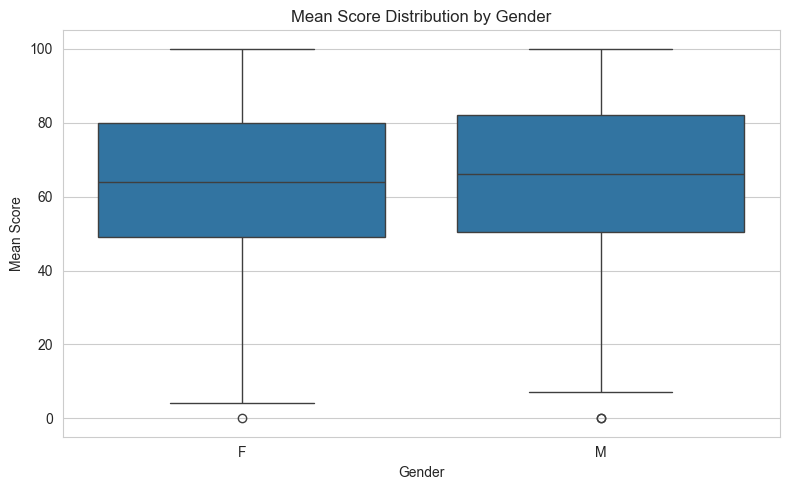

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
F,1960.0,63.822704,20.561852,0.0,49.0,64.0,80.0,100.0
M,4038.0,65.588410,20.411053,0.0,50.5,66.0,82.0,100.0


In [8]:
# 第二题：读取上周结果表，绘制 gender 与 mean_score 的箱线图
student_score_info = pd.read_csv("student_info_with_mean_score.csv", encoding="utf-8-sig")

# mean_score 缺失表示没有可用的平均考试成绩，不属于异常值，因此作图前剔除
boxplot_data = student_score_info[["gender", "mean_score"]].dropna(subset=["mean_score"])

plt.figure(figsize=(8, 5))
sns.boxplot(data=boxplot_data, x="gender", y="mean_score")
plt.title("Mean Score Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean Score")
plt.tight_layout()
plt.savefig("week3_chart_2_mean_score_by_gender.png", dpi=300, bbox_inches="tight")
plt.show()

boxplot_data.groupby("gender")["mean_score"].describe()


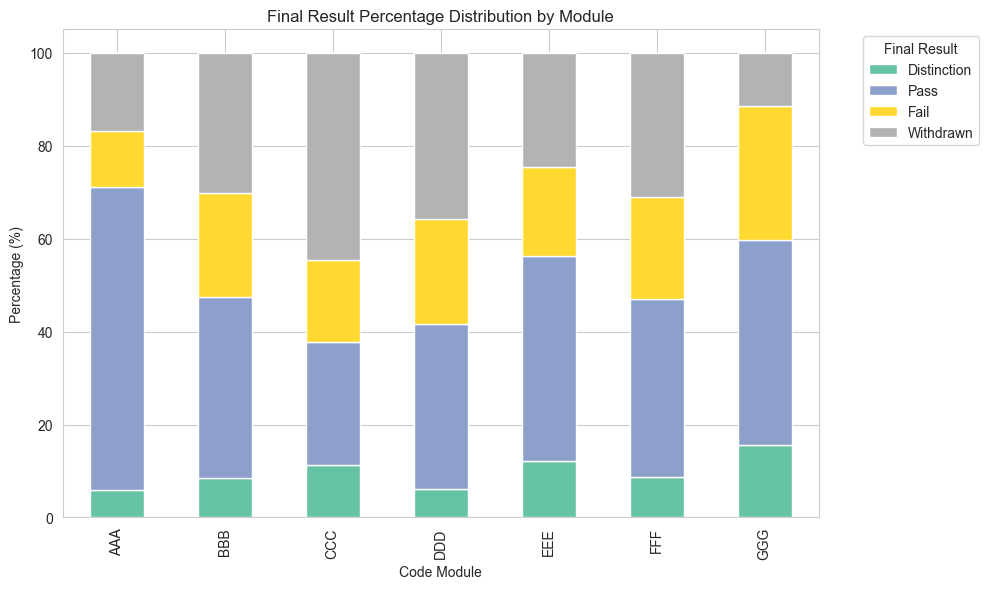

final_result,Distinction,Pass,Fail,Withdrawn
code_module,,,,
AAA,5.88,65.11,12.17,16.84
BBB,8.56,38.91,22.34,30.19
CCC,11.23,26.61,17.61,44.54
DDD,6.11,35.51,22.51,35.87
EEE,12.13,44.10,19.15,24.61
FFF,8.63,38.37,22.04,30.96
GGG,15.63,44.12,28.73,11.52


In [9]:
# 第三题：绘制各课程最终结果百分比分布的堆叠柱状图
student_info_result = pd.read_csv("studentInfo.csv", encoding="gb18030")

result_percent = (
    student_info_result.groupby(["code_module", "final_result"])
    .size()
    .unstack(fill_value=0)
)
result_percent = result_percent.div(result_percent.sum(axis=1), axis=0) * 100

result_order = ["Distinction", "Pass", "Fail", "Withdrawn"]
existing_columns = [col for col in result_order if col in result_percent.columns]
result_percent = result_percent[existing_columns]

result_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="Set2"
)
plt.title("Final Result Percentage Distribution by Module")
plt.xlabel("Code Module")
plt.ylabel("Percentage (%)")
plt.legend(title="Final Result", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("week3_chart_3_final_result_by_module.png", dpi=300, bbox_inches="tight")
plt.show()

result_percent.round(2)


## AI对话记录
query1：
查看 `第三周作业.ipynb` 的题目要求，并按题目一项项完成。

a_newer1：
读取 Notebook 后确认第三周作业共有 3 项数据可视化任务：1. 绘制 `imd_band` 与学生通过率的折线图；2. 绘制 `gender` 与 `mean_score` 的箱线图；3. 绘制各课程 `final_result` 百分比分布的堆叠柱状图。之后决定按“一题一个代码框”的方式逐项完成。

query2：
第一题打算怎么做？

a_newer2：
第一题使用 `studentInfo.csv`。先清洗 `imd_band` 中错误显示的 `10月20日`，统一改回 `10-20%`；再把 `final_result` 中的 `Pass` 和 `Distinction` 视为“通过”，按 `imd_band` 分组计算通过率，并按贫困指数区间顺序绘制折线图，同时输出对应的通过率结果表方便核对。

query3：
写第一题代码。

a_newer3：
在 `第三周作业.ipynb` 中写入第一题代码，完成数据读取、`imd_band` 清洗、通过率计算和折线图绘制。运行后得到的图表显示：随着 `imd_band` 提高，学生通过率整体呈上升趋势。

query4：
第二题是不是可以直接用上周已经保存好的“学生信息 + 平均成绩”结果表，而不用重新计算 `mean_score`？

a_newer4：
可以，直接读取上周导出的 `student_info_with_mean_score.csv` 更清晰，也避免重复计算。第二题据此只保留 `gender` 和 `mean_score` 两列，并用它们绘制箱线图。

query5：
为什么第二题要去掉 `mean_score` 为空的记录？这样会不会影响异常值判断？

a_newer5：
`mean_score` 为空表示该学生没有可用的平均考试成绩，这属于缺失值，不是异常值。箱线图比较的是有效数值的分布，中位数、四分位数和异常值判定都应基于真实成绩，因此作图前剔除缺失值是合理的，不会破坏异常值判断；真正会影响图形的是把缺失值错误地填成某个数字，例如 `0`。

query6：
写第二题代码，并解释图里异常值应该怎么理解。

a_newer6：
在 Notebook 中新增第二题代码框，读取 `student_info_with_mean_score.csv`，删除 `mean_score` 缺失记录，绘制 `gender` 与 `mean_score` 的箱线图，并输出按性别分组的描述统计。运行结果显示：男生的平均分和中位数略高于女生，但两组分布整体接近。图中靠近 `0` 的圆点表示低端异常值；异常值不是“靠近 0 才算”，而是落在箱线图正常范围之外的点。之所以看起来每组只有一个圆点，是因为多个同值异常点可能重叠在同一位置。

query7：
第三题打算怎么做？

a_newer7：
第三题直接使用 `studentInfo.csv`，因为 `code_module` 和 `final_result` 都在这张表里。先按 `code_module` 和 `final_result` 统计每门课各结果的人数，再将人数转换为课程内部百分比，使每门课的柱子总和为 `100%`，最后按 `Distinction`、`Pass`、`Fail`、`Withdrawn` 的顺序绘制堆叠柱状图，并输出百分比结果表。

query8：
写第三题代码。

a_newer8：
在 `第三周作业.ipynb` 中新增第三题代码框，完成按课程和最终结果统计百分比、绘制堆叠柱状图以及输出 `result_percent` 结果表。

query9：
作业要求还要提交三张绘制的图表，能否通过代码保存到文件夹里？

a_newer9：
在三道题的代码中分别加入 `plt.savefig(...)`，使每次运行代码框时都会自动把图保存为图片文件，文件名分别为：`week3_chart_1_pass_rate_by_imd.png`、`week3_chart_2_mean_score_by_gender.png`、`week3_chart_3_final_result_by_module.png`，并说明可以通过重新运行三个代码框，在当前作业目录中自动生成这三张图。
